In [1]:

# ==========================================
# CUSTOMER SEGMENTATION AND PREDICTIVE ANALYTICS
# Step 1: Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from scipy.cluster.hierarchy import dendrogram, linkage

import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:

# ==========================================
# Step 2: Load Dataset
# ==========================================

from google.colab import files

uploaded = files.upload()

# Read uploaded Excel file
file_name = next(iter(uploaded))

df = pd.read_excel(file_name)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

# Display first five records
df.head()

Saving Online Retail.xlsx to Online Retail.xlsx
Dataset loaded successfully!
Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:

# Dataset information
print("Dataset Information:")
print("--------------------")

df.info()

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

# Column names
print("\nDataset Columns:")
print(df.columns.tolist())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Statistical Summary:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303



Dataset Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:

# ==========================================
# STEP 6.1: Identify Cancelled Transactions
# ==========================================

# Count cancelled invoices
cancelled = df[
    df['InvoiceNo'].astype(str).str.startswith('C')
]

print("Total Cancelled Transactions:", len(cancelled))

print("\nSample Cancelled Transactions:")
display(cancelled.head())

# Count negative quantities
print("\nNegative Quantity Records:",
      (df['Quantity'] <= 0).sum())

# Count negative or zero prices
print("Invalid Unit Price Records:",
      (df['UnitPrice'] <= 0).sum())

# Count missing customer IDs
print("Missing Customer IDs:",
      df['CustomerID'].isnull().sum())

Total Cancelled Transactions: 9288

Sample Cancelled Transactions:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom



Negative Quantity Records: 10624
Invalid Unit Price Records: 2517
Missing Customer IDs: 135080


In [6]:

# ==========================================
# STEP 6.2: Data Cleaning
# ==========================================

print("Original Dataset Shape:", df.shape)

# Create a copy of original dataset
df_clean = df.copy()

# Remove missing Customer IDs
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remove cancelled transactions
df_clean = df_clean[
    ~df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

# Remove invalid quantities
df_clean = df_clean[df_clean['Quantity'] > 0]

# Remove invalid prices
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Remove duplicate records
df_clean = df_clean.drop_duplicates()

# Convert CustomerID into integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

print("\nDataset after Cleaning:", df_clean.shape)

print("\nRemaining Missing Values:")
print(df_clean.isnull().sum())

print("\nFirst Five Cleaned Records:")
display(df_clean.head())

Original Dataset Shape: (541909, 8)

Dataset after Cleaning: (392692, 8)

Remaining Missing Values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

First Five Cleaned Records:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [7]:

# ==========================================
# STEP 6.3: Calculate Transaction Amount
# ==========================================

df_clean['TotalAmount'] = (
    df_clean['Quantity'] * df_clean['UnitPrice']
)

print("Transaction Amount Calculated!")

display(
    df_clean[
        ['InvoiceNo', 'Quantity', 'UnitPrice', 'TotalAmount']
    ].head()
)

Transaction Amount Calculated!


,InvoiceNo,Quantity,UnitPrice,TotalAmount
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34


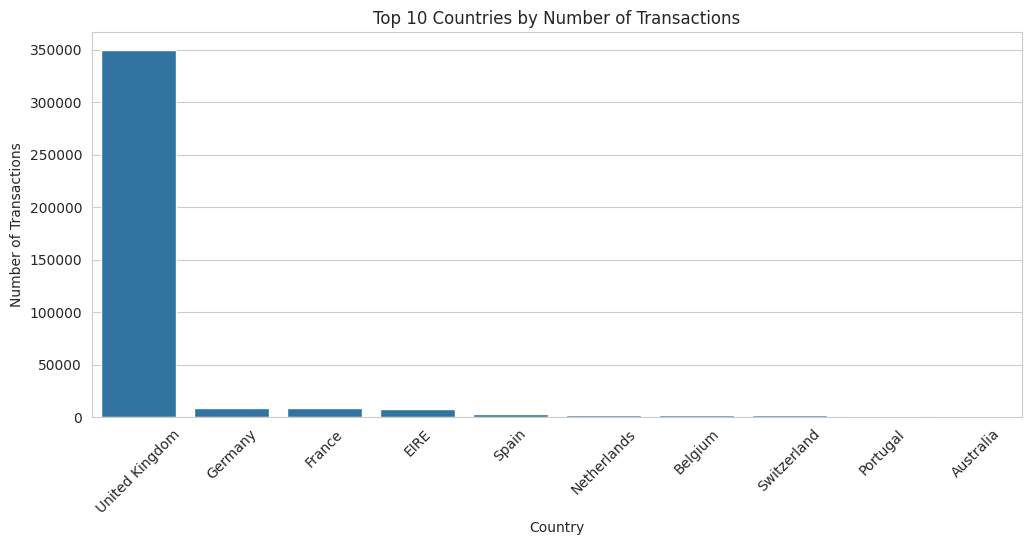

In [8]:

country_counts = df_clean['Country'].value_counts().head(10)

plt.figure(figsize=(12, 5))

sns.barplot(
    x=country_counts.index,
    y=country_counts.values
)

plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

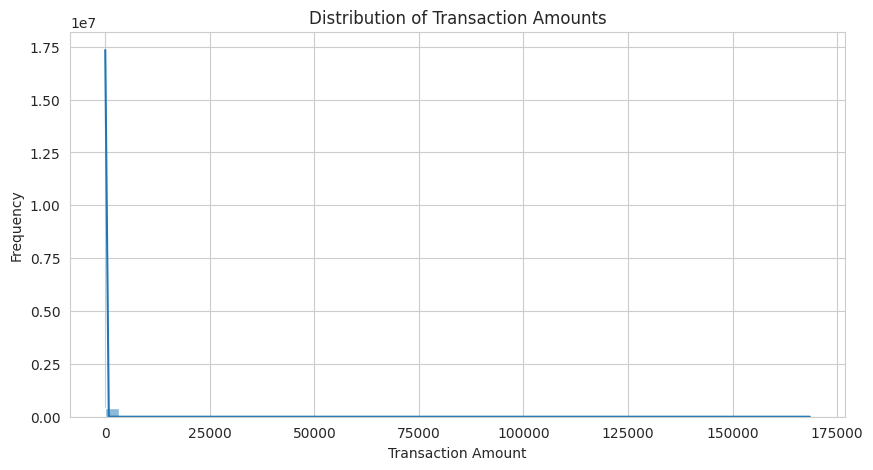

In [9]:

plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean['TotalAmount'],
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

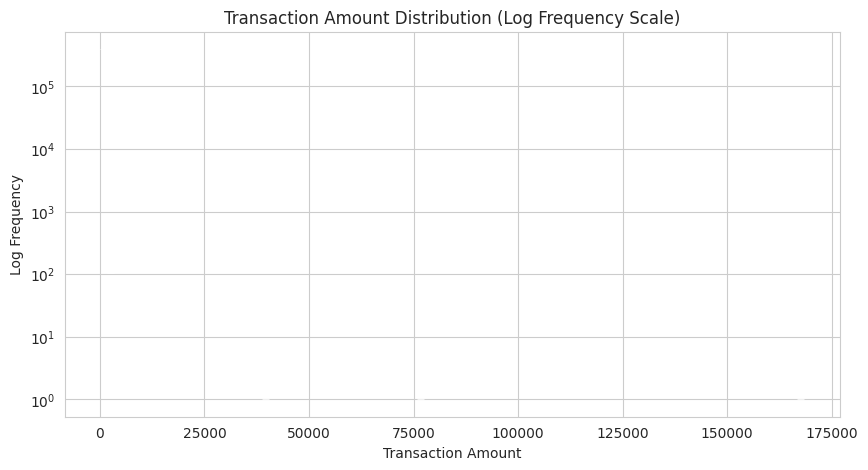

In [10]:

# Improved Transaction Amount Distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean['TotalAmount'],
    bins=100,
    log_scale=(False, True)
)

plt.title("Transaction Amount Distribution (Log Frequency Scale)")
plt.xlabel("Transaction Amount")
plt.ylabel("Log Frequency")

plt.show()

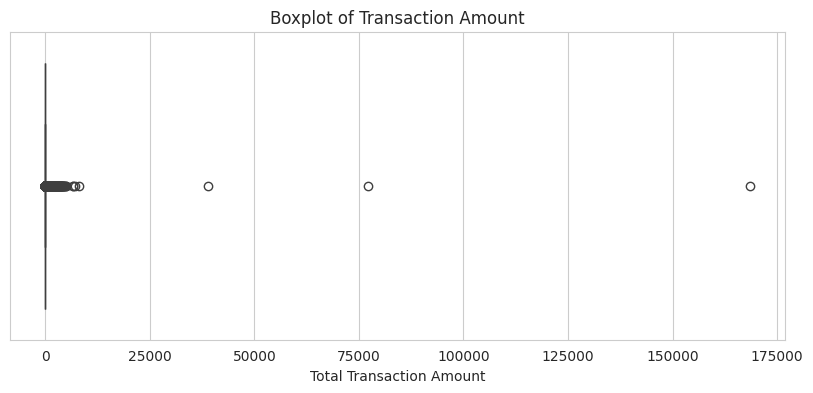

In [11]:

plt.figure(figsize=(10, 4))

sns.boxplot(x=df_clean['TotalAmount'])

plt.title("Boxplot of Transaction Amount")
plt.xlabel("Total Transaction Amount")

plt.show()

In [12]:

# ==========================================
# STEP 8: RFM FEATURE ENGINEERING
# ==========================================

# Set reference date as one day after last transaction
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group transaction data customer-wise
rfm = df_clean.groupby('CustomerID').agg({

    'InvoiceDate': lambda x: (reference_date - x.max()).days,

    'InvoiceNo': 'nunique',

    'TotalAmount': 'sum',

    'Quantity': 'sum'

})

# Rename columns
rfm.rename(columns={

    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary',
    'Quantity': 'TotalQuantity'

}, inplace=True)

# Calculate average transaction value
rfm['AvgTransactionValue'] = (
    rfm['Monetary'] / rfm['Frequency']
)

# Calculate purchase frequency per active month
customer_months = (
    df_clean.groupby('CustomerID')['InvoiceDate']
    .apply(lambda x: x.dt.to_period('M').nunique())
)

rfm['PurchaseFrequency'] = (
    rfm['Frequency'] / customer_months
)

print("RFM Feature Engineering Completed!")

print("\nRFM Dataset Shape:", rfm.shape)

display(rfm.head())

print("\nRFM Statistical Summary:")
display(rfm.describe())

RFM Feature Engineering Completed!

RFM Dataset Shape: (4338, 6)


,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue,PurchaseFrequency
CustomerID,,,,,,
12346,326,1,77183.60,74215,77183.600000,1.0
12347,2,7,4310.00,2458,615.714286,1.0
12348,75,4,1797.24,2341,449.310000,1.0
12349,19,1,1757.55,631,1757.550000,1.0
12350,310,1,334.40,197,334.400000,1.0



RFM Statistical Summary:


,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue,PurchaseFrequency
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081,1187.644537,417.645735,1.225594
std,100.014169,7.697998,8985.230220,5043.619654,1796.511343,0.765747
min,1.000000,1.000000,3.750000,1.000000,3.450000,1.000000
25%,18.000000,1.000000,306.482500,159.000000,177.867083,1.000000
50%,51.000000,2.000000,668.570000,378.000000,291.940000,1.000000
75%,142.000000,5.000000,1660.597500,989.750000,428.280625,1.250000
max,374.000000,209.000000,280206.020000,196915.000000,84236.250000,34.000000


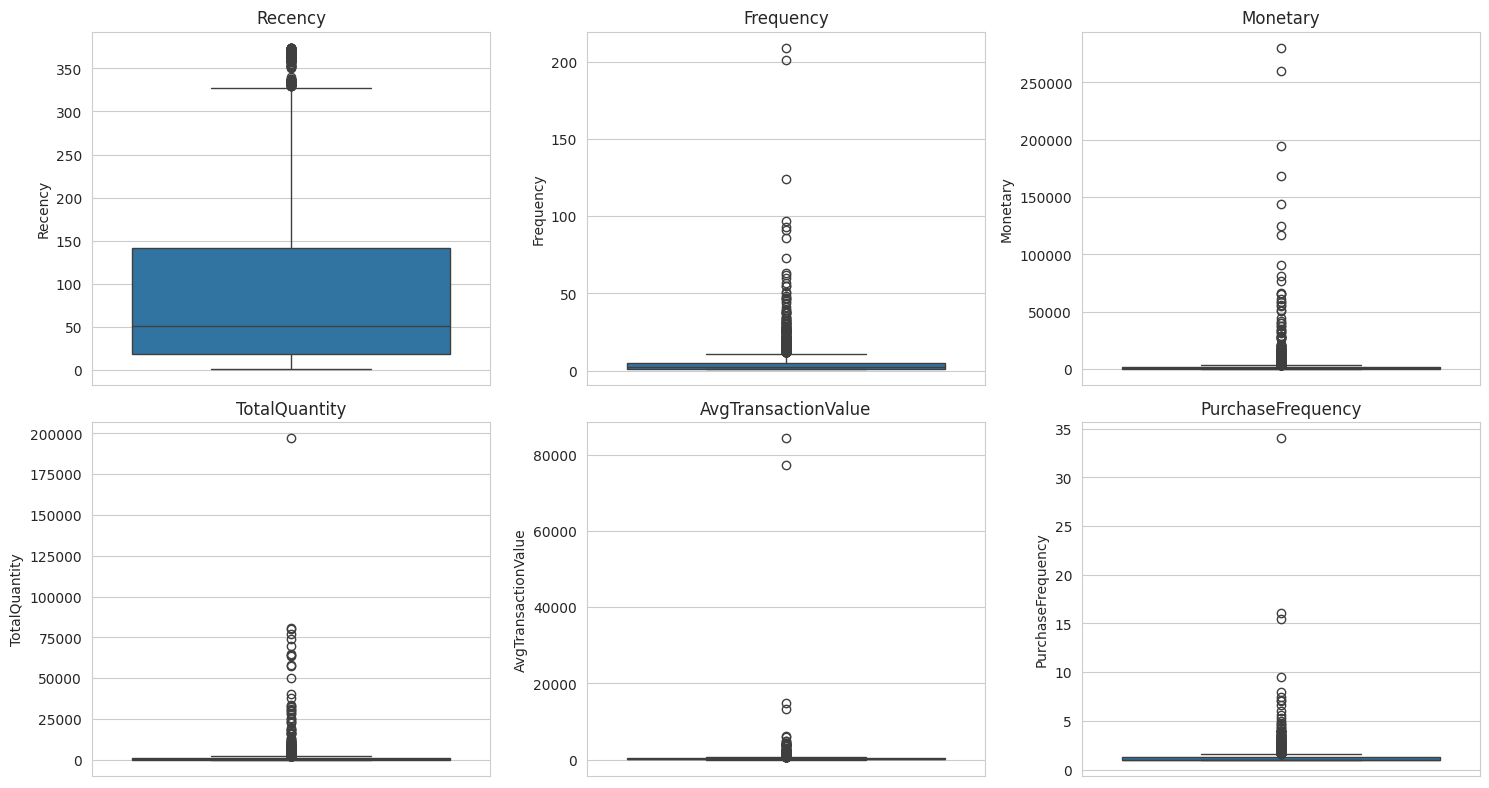


Skewness of RFM Features:
Recency                 1.246048
Frequency              12.067031
Monetary               19.339368
TotalQuantity          20.383991
AvgTransactionValue    41.692422
PurchaseFrequency      22.735246
dtype: float64


In [13]:

# ==========================================
# STEP 9: OUTLIER ANALYSIS
# ==========================================

plt.figure(figsize=(15, 8))

for i, col in enumerate(rfm.columns):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=rfm[col])
    plt.title(col)

plt.tight_layout()
plt.show()

print("\nSkewness of RFM Features:")
print(rfm.skew())

In [14]:

# ==========================================
# STEP 10: OUTLIER TREATMENT
# ==========================================

# Create a separate copy
rfm_processed = rfm.copy()

# Apply percentile capping
for col in rfm_processed.columns:

    lower_limit = rfm_processed[col].quantile(0.01)
    upper_limit = rfm_processed[col].quantile(0.99)

    rfm_processed[col] = rfm_processed[col].clip(
        lower_limit,
        upper_limit
    )

print("Outlier Treatment Completed!")

print("\nBefore Treatment:")
display(rfm.describe())

print("\nAfter Treatment:")
display(rfm_processed.describe())

Outlier Treatment Completed!

Before Treatment:


,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue,PurchaseFrequency
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081,1187.644537,417.645735,1.225594
std,100.014169,7.697998,8985.230220,5043.619654,1796.511343,0.765747
min,1.000000,1.000000,3.750000,1.000000,3.450000,1.000000
25%,18.000000,1.000000,306.482500,159.000000,177.867083,1.000000
50%,51.000000,2.000000,668.570000,378.000000,291.940000,1.000000
75%,142.000000,5.000000,1660.597500,989.750000,428.280625,1.250000
max,374.000000,209.000000,280206.020000,196915.000000,84236.250000,34.000000



After Treatment:


,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue,PurchaseFrequency
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,92.500692,4.008760,1592.644234,922.312946,364.219891,1.198970
std,99.914624,4.863497,2788.353651,1582.815821,313.065525,0.389952
min,1.000000,1.000000,52.200000,12.000000,43.311000,1.000000
25%,18.000000,1.000000,306.482500,159.000000,177.867083,1.000000
50%,51.000000,2.000000,668.570000,378.000000,291.940000,1.000000
75%,142.000000,5.000000,1660.597500,989.750000,428.280625,1.250000
max,369.000000,30.000000,19780.487800,11016.240000,2031.161200,3.052500


Log Transformation Completed!


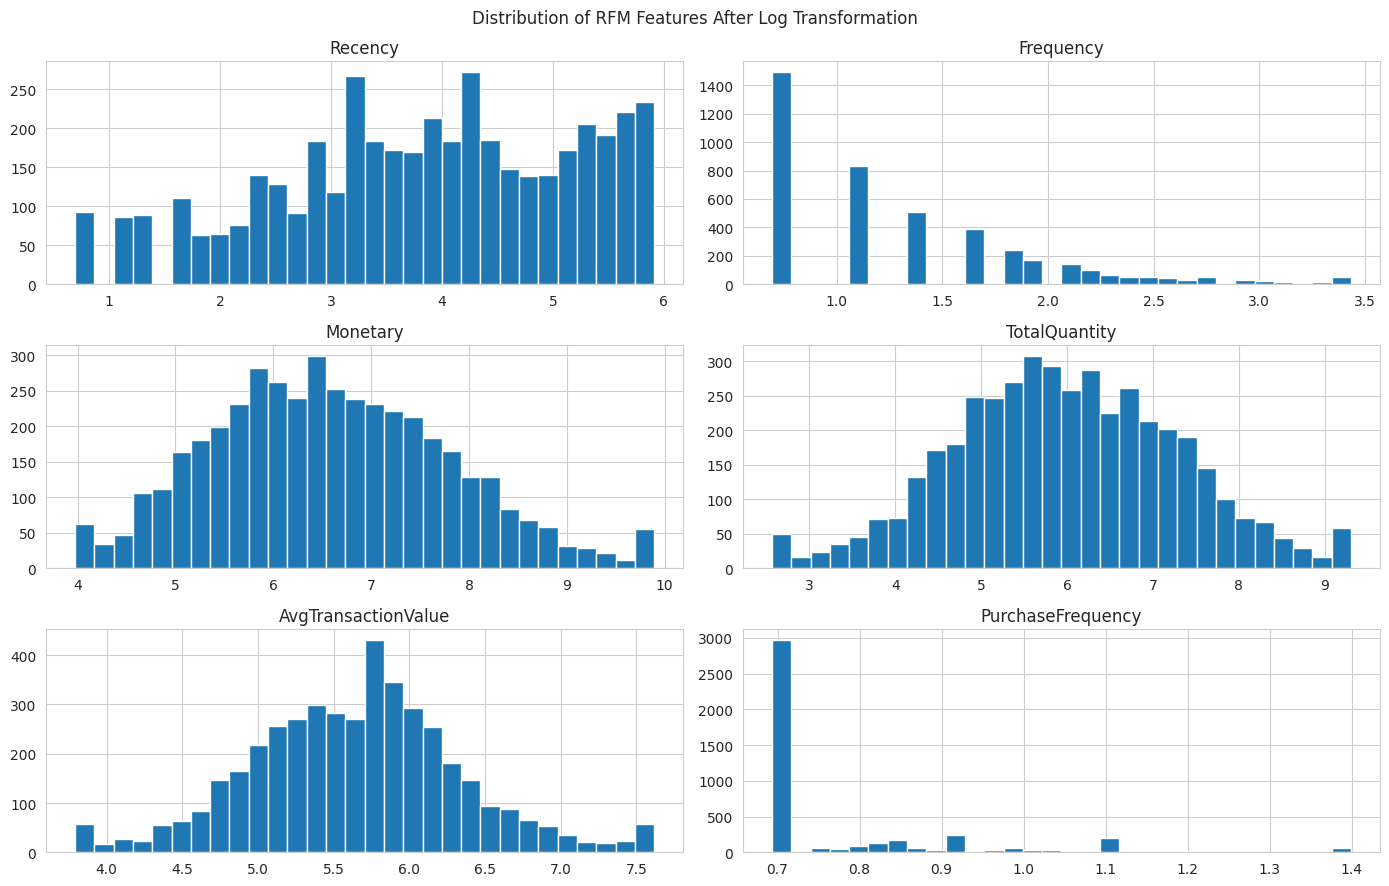

In [15]:

# ==========================================
# STEP 11: LOG TRANSFORMATION
# ==========================================

rfm_log = np.log1p(rfm_processed)

print("Log Transformation Completed!")

# Visualize transformed features
rfm_log.hist(figsize=(14, 9), bins=30)

plt.suptitle("Distribution of RFM Features After Log Transformation")
plt.tight_layout()
plt.show()

In [16]:

# ==========================================
# STEP 12: FEATURE SCALING
# ==========================================

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

# Convert back to DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm_log.columns,
    index=rfm_log.index
)

print("Feature Scaling Completed!")

print("\nScaled Dataset:")
display(rfm_scaled.head())

print("\nMean of Scaled Features:")
print(rfm_scaled.mean().round(2))

print("\nStandard Deviation:")
print(rfm_scaled.std().round(2))

Feature Scaling Completed!

Scaled Dataset:


,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue,PurchaseFrequency
CustomerID,,,,,,
12346,1.462228,-0.974100,2.724304,2.527804,2.811752,-0.546572
12347,-2.038890,1.110952,1.469394,1.388536,1.111341,-0.546572
12348,0.373218,0.404045,0.749216,1.351502,0.662913,-0.546572
12349,-0.623084,-0.974100,0.730833,0.356444,2.605540,-0.546572
12350,1.424788,-0.974100,-0.633907,-0.525235,0.242801,-0.546572



Mean of Scaled Features:
Recency               -0.0
Frequency              0.0
Monetary              -0.0
TotalQuantity         -0.0
AvgTransactionValue    0.0
PurchaseFrequency     -0.0
dtype: float64

Standard Deviation:
Recency                1.0
Frequency              1.0
Monetary               1.0
TotalQuantity          1.0
AvgTransactionValue    1.0
PurchaseFrequency      1.0
dtype: float64


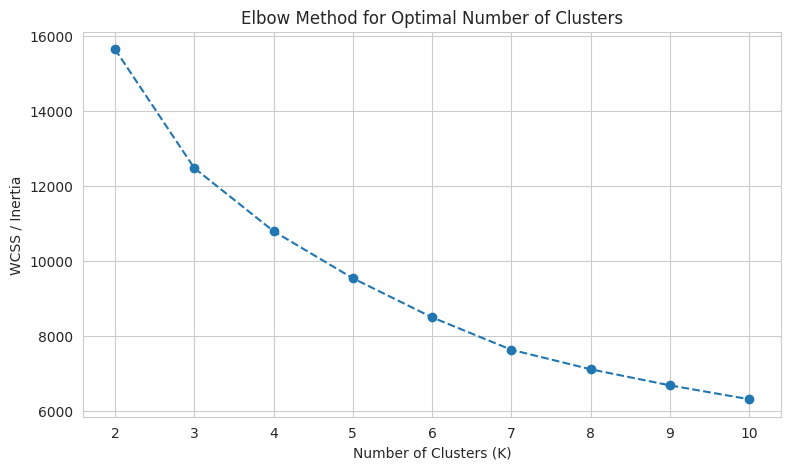

In [17]:

# ==========================================
# STEP 13: ELBOW METHOD
# ==========================================

inertia = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(9, 5))

plt.plot(
    K,
    inertia,
    marker='o',
    linestyle='--'
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.xticks(K)
plt.grid(True)

plt.show()

K = 2, Silhouette Score = 0.3537
K = 3, Silhouette Score = 0.2633
K = 4, Silhouette Score = 0.2361
K = 5, Silhouette Score = 0.2528
K = 6, Silhouette Score = 0.2525
K = 7, Silhouette Score = 0.2435
K = 8, Silhouette Score = 0.2386
K = 9, Silhouette Score = 0.2282
K = 10, Silhouette Score = 0.2269


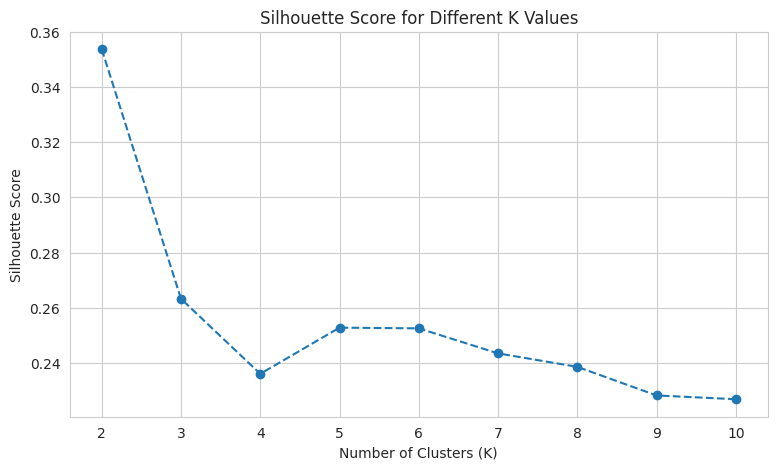

In [18]:

# ==========================================
# STEP 14: SILHOUETTE SCORE
# ==========================================

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")


# Plot Silhouette Scores
plt.figure(figsize=(9, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o',
    linestyle='--'
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [19]:

# Compare clustering evaluation results

comparison = pd.DataFrame({
    'Number of Clusters (K)': range(2, 11),
    'Silhouette Score': silhouette_scores
})

display(
    comparison.sort_values(
        by='Silhouette Score',
        ascending=False
    ).reset_index(drop=True)
)

,Number of Clusters (K),Silhouette Score
0,2,0.353676
1,3,0.263252
2,5,0.252789
3,6,0.252535
4,7,0.243467
5,8,0.238588
6,4,0.236055
7,9,0.228228
8,10,0.226858


In [20]:
optimal_k = 3  # Update after evaluating your results

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("K-Means Clustering Completed!")

print("\nCustomers in Each Cluster:")
print(rfm['Cluster'].value_counts().sort_index())

K-Means Clustering Completed!

Customers in Each Cluster:
Cluster
0    1657
1     859
2    1822
Name: count, dtype: int64


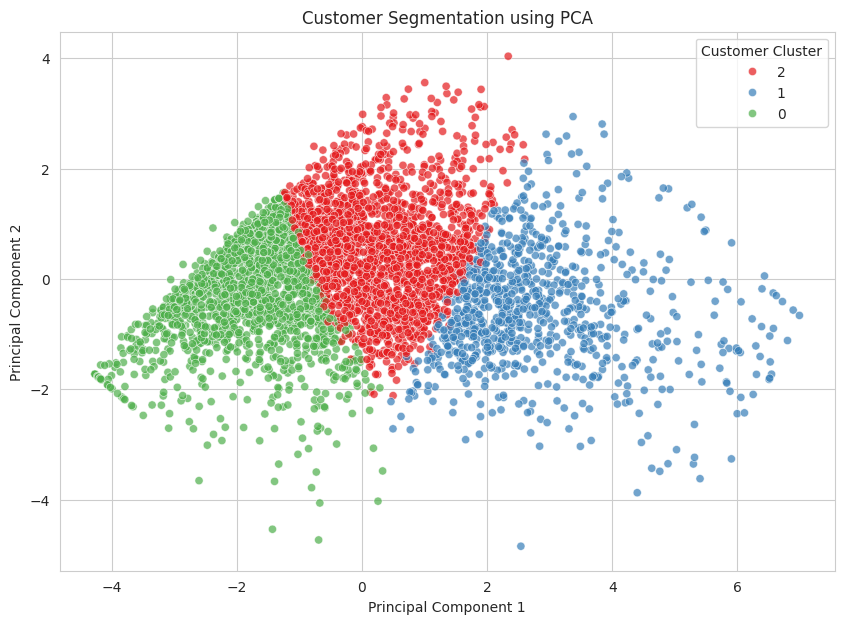

Explained Variance Ratio:
[0.6134019  0.19616238]
Total Variance Explained: 80.96 %


In [21]:

# ==========================================
# STEP 16: PCA 2D VISUALIZATION
# ==========================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_components = pca.fit_transform(rfm_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(
    pca_components,
    columns=['PC1', 'PC2'],
    index=rfm.index
)

# Add cluster labels
pca_df['Cluster'] = rfm['Cluster'].astype(str)

# Plot clusters
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=35,
    alpha=0.7
)

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Customer Cluster")

plt.show()

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total Variance Explained:",
    round(sum(pca.explained_variance_ratio_) * 100, 2),
    "%"
)

In [22]:

# ==========================================
# STEP 17: CUSTOMER CLUSTER PROFILING
# ==========================================

# Calculate average RFM values for each cluster
cluster_profile = rfm.groupby('Cluster').agg({

    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'TotalQuantity': 'mean',
    'AvgTransactionValue': 'mean',
    'PurchaseFrequency': 'mean'

}).round(2)

print("Customer Cluster Profiles:")
display(cluster_profile)

Customer Cluster Profiles:


,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue,PurchaseFrequency
Cluster,,,,,,
0,151.26,1.50,256.44,143.72,191.28,1.07
1,21.75,12.43,7246.02,4100.31,635.14,1.80
2,72.50,2.95,1228.30,763.83,520.97,1.10


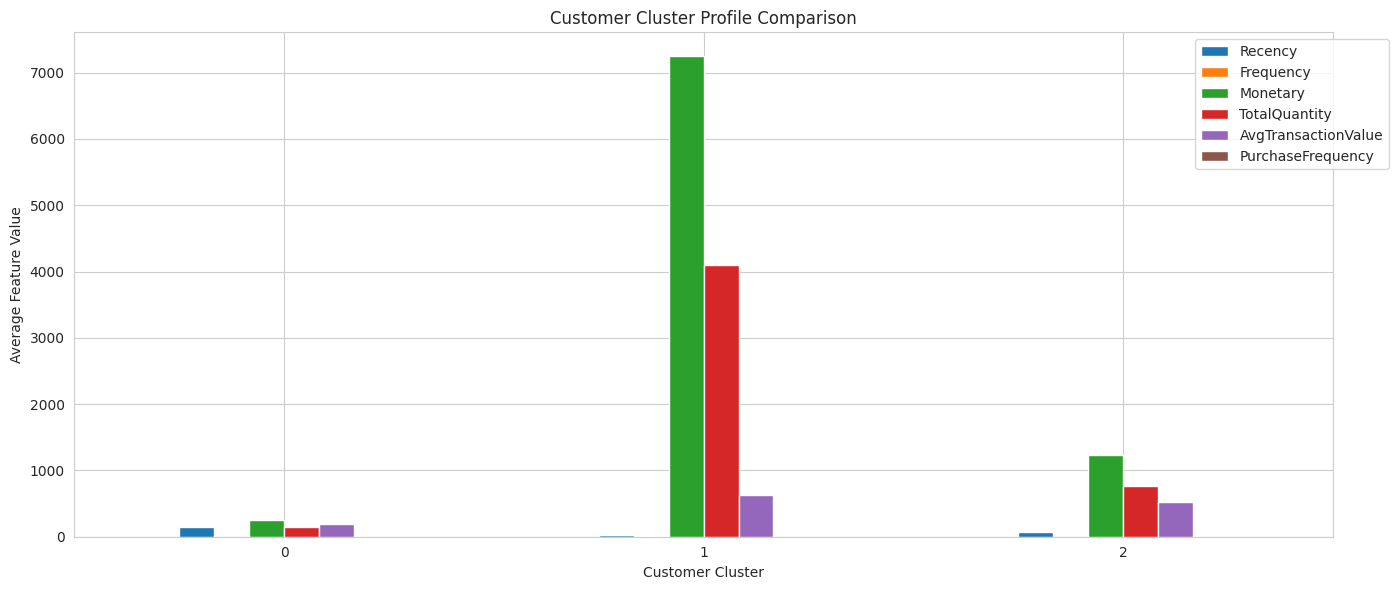

In [23]:

# Plot cluster profiles
cluster_profile.plot(
    kind='bar',
    figsize=(14, 6)
)

plt.title("Customer Cluster Profile Comparison")
plt.xlabel("Customer Cluster")
plt.ylabel("Average Feature Value")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

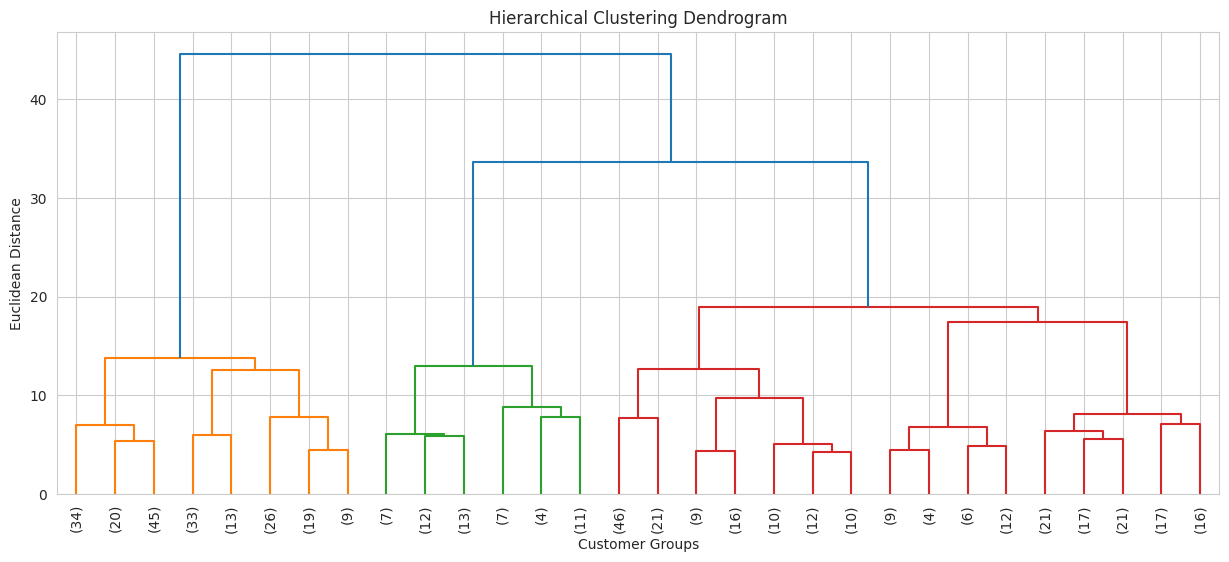

In [24]:

# ==========================================
# STEP 18: HIERARCHICAL CLUSTERING
# ==========================================

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Select 500 customers for dendrogram
sample_data = rfm_scaled.sample(
    n=500,
    random_state=42
)

# Generate linkage matrix
linked = linkage(
    sample_data,
    method='ward'
)

# Plot dendrogram
plt.figure(figsize=(15, 6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customer Groups")
plt.ylabel("Euclidean Distance")

plt.show()

In [25]:

# Apply Hierarchical Clustering

hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

hierarchical_labels = hierarchical.fit_predict(rfm_scaled)

# Calculate Silhouette Score
hierarchical_silhouette = silhouette_score(
    rfm_scaled,
    hierarchical_labels
)

kmeans_silhouette = silhouette_score(
    rfm_scaled,
    rfm['Cluster']
)

print("K-Means Silhouette Score:",
      round(kmeans_silhouette, 4))

print("Hierarchical Silhouette Score:",
      round(hierarchical_silhouette, 4))

K-Means Silhouette Score: 0.2633
Hierarchical Silhouette Score: 0.2061


In [26]:

# ==========================================
# STEP 19: IDENTIFY HIGH-VALUE CUSTOMERS
# ==========================================

# Display average purchasing behavior of each cluster
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'TotalQuantity': 'mean',
    'AvgTransactionValue': 'mean',
    'PurchaseFrequency': 'mean'
}).round(2)

print("CUSTOMER CLUSTER ANALYSIS")
display(cluster_profile)

# Sort clusters by monetary value
print("\nClusters Ranked by Average Monetary Value:")

display(
    cluster_profile.sort_values(
        by='Monetary',
        ascending=False
    )
)

CUSTOMER CLUSTER ANALYSIS


,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue,PurchaseFrequency
Cluster,,,,,,
0,151.26,1.50,256.44,143.72,191.28,1.07
1,21.75,12.43,7246.02,4100.31,635.14,1.80
2,72.50,2.95,1228.30,763.83,520.97,1.10



Clusters Ranked by Average Monetary Value:


,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue,PurchaseFrequency
Cluster,,,,,,
1,21.75,12.43,7246.02,4100.31,635.14,1.80
2,72.50,2.95,1228.30,763.83,520.97,1.10
0,151.26,1.50,256.44,143.72,191.28,1.07


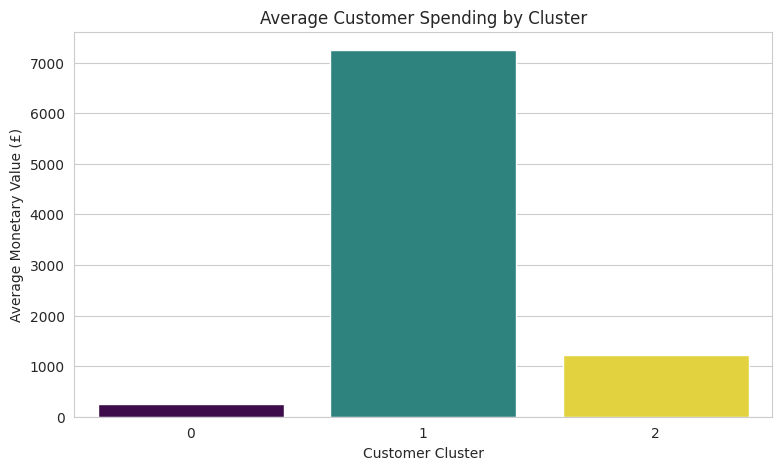

In [27]:

plt.figure(figsize=(9, 5))

sns.barplot(
    x=cluster_profile.index,
    y=cluster_profile['Monetary'],
    hue=cluster_profile.index,
    palette='viridis',
    legend=False
)

plt.title("Average Customer Spending by Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Average Monetary Value (£)")

plt.show()

In [28]:

# ==========================================
# STEP 20.1: FINAL CLUSTER PROFILE
# ==========================================

cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'TotalQuantity': 'mean',
    'AvgTransactionValue': 'mean',
    'PurchaseFrequency': 'mean'
}).round(2)

display(cluster_profile)

,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue,PurchaseFrequency
Cluster,,,,,,
0,151.26,1.50,256.44,143.72,191.28,1.07
1,21.75,12.43,7246.02,4100.31,635.14,1.80
2,72.50,2.95,1228.30,763.83,520.97,1.10


In [29]:

# ==========================================
# STEP 20.2: CREATE HIGH-VALUE CUSTOMER LABEL
# ==========================================

high_value_cluster = 1

# Create binary target variable
rfm['HighValue'] = (
    rfm['Cluster'] == high_value_cluster
).astype(int)

print("High-Value Customer Identification Completed!")

print("\nTarget Distribution:")
print(rfm['HighValue'].value_counts())

print("\nTarget Percentage:")
print(
    (rfm['HighValue'].value_counts(normalize=True) * 100).round(2)
)

print("\nSample Dataset:")
display(rfm.head())

High-Value Customer Identification Completed!

Target Distribution:
HighValue
0    3479
1     859
Name: count, dtype: int64

Target Percentage:
HighValue
0    80.2
1    19.8
Name: proportion, dtype: float64

Sample Dataset:


,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue,PurchaseFrequency,Cluster,HighValue
CustomerID,,,,,,,,
12346,326,1,77183.60,74215,77183.600000,1.0,2,0
12347,2,7,4310.00,2458,615.714286,1.0,1,1
12348,75,4,1797.24,2341,449.310000,1.0,2,0
12349,19,1,1757.55,631,1757.550000,1.0,2,0
12350,310,1,334.40,197,334.400000,1.0,0,0


In [30]:

# ==========================================
# STEP 21: PREPARE CLASSIFICATION DATA
# ==========================================

# Features used for prediction
X = rfm[
    [
        'Recency',
        'Frequency',
        'TotalQuantity',
        'AvgTransactionValue',
        'PurchaseFrequency'
    ]
]

# Target variable
y = rfm['HighValue']

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features for SVM
classification_scaler = StandardScaler()

X_train_scaled = classification_scaler.fit_transform(X_train)
X_test_scaled = classification_scaler.transform(X_test)

print("Training and Testing Split Completed!")

print("Training Records:", X_train.shape[0])
print("Testing Records:", X_test.shape[0])

print("\nTraining Target Distribution:")
print(y_train.value_counts())

Training and Testing Split Completed!
Training Records: 3470
Testing Records: 868

Training Target Distribution:
HighValue
0    2783
1     687
Name: count, dtype: int64


In [31]:

# ==========================================
# STEP 22: RANDOM FOREST CLASSIFIER
# ==========================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Training Completed!")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

Random Forest Training Completed!

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       696
           1       0.99      0.90      0.94       172

    accuracy                           0.98       868
   macro avg       0.98      0.95      0.96       868
weighted avg       0.98      0.98      0.98       868



In [32]:

# ==========================================
# STEP 23: SUPPORT VECTOR MACHINE
# ==========================================

svm_model = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

svm_predictions = svm_model.predict(X_test_scaled)

svm_probabilities = svm_model.predict_proba(X_test_scaled)[:, 1]

print("SVM Training Completed!")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svm_predictions,
        zero_division=0
    )
)

SVM Training Completed!

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       696
           1       0.87      0.97      0.92       172

    accuracy                           0.97       868
   macro avg       0.93      0.97      0.95       868
weighted avg       0.97      0.97      0.97       868



In [33]:

# ==========================================
# STEP 24: MODEL EVALUATION
# ==========================================

results = []

models = {
    'Random Forest': (rf_predictions, rf_probabilities),
    'SVM': (svm_predictions, svm_probabilities)
}

for name, (predictions, probabilities) in models.items():

    results.append({

        'Model': name,

        'Accuracy': accuracy_score(
            y_test, predictions
        ),

        'Precision': precision_score(
            y_test, predictions, zero_division=0
        ),

        'Recall': recall_score(
            y_test, predictions, zero_division=0
        ),

        'F1 Score': f1_score(
            y_test, predictions, zero_division=0
        ),

        'ROC-AUC': roc_auc_score(
            y_test, probabilities
        )
    })

results_df = pd.DataFrame(results)

print("MODEL PERFORMANCE COMPARISON")

display(results_df.round(4))

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9781,0.9873,0.9012,0.9422,0.9982
1,SVM,0.9654,0.8698,0.9709,0.9176,0.9962


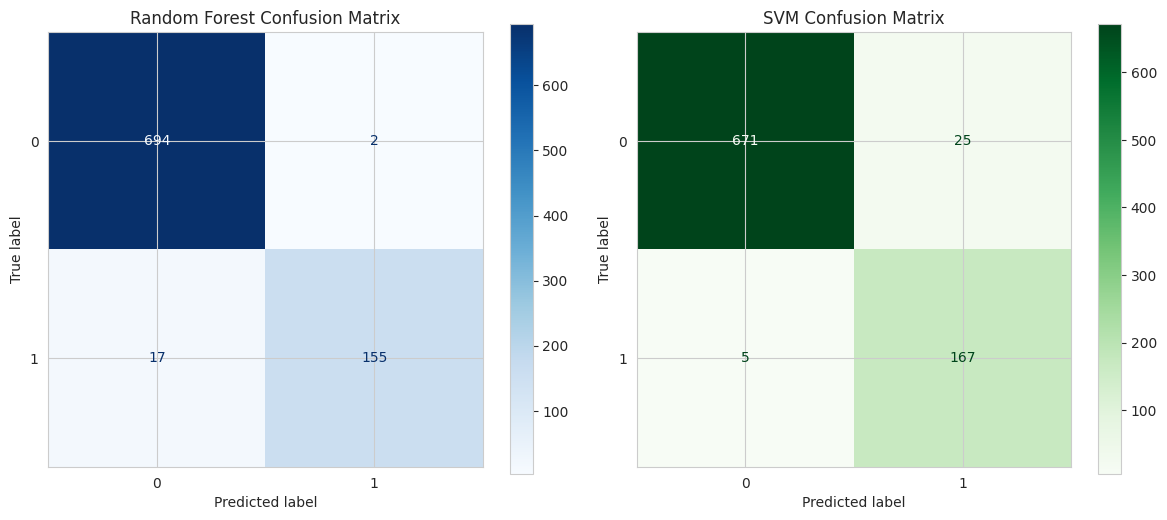

In [34]:

# ==========================================
# STEP 25: CONFUSION MATRICES
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    ax=axes[0],
    cmap='Blues'
)

axes[0].set_title("Random Forest Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_predictions,
    ax=axes[1],
    cmap='Greens'
)

axes[1].set_title("SVM Confusion Matrix")

plt.tight_layout()
plt.show()

,Feature,Importance
1,Frequency,0.346184
4,PurchaseFrequency,0.297578
2,TotalQuantity,0.213832
0,Recency,0.101261
3,AvgTransactionValue,0.041145


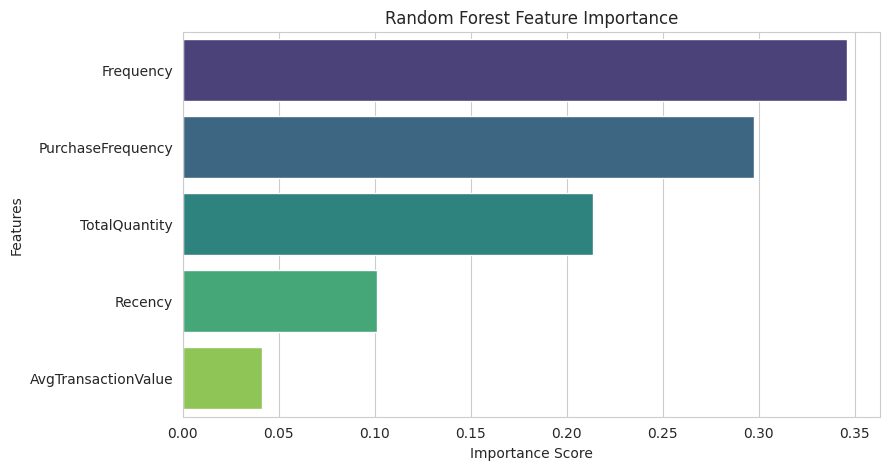

In [35]:

# ==========================================
# STEP 26: FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf_model.feature_importances_

}).sort_values(
    by='Importance',
    ascending=False
)

display(importance)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

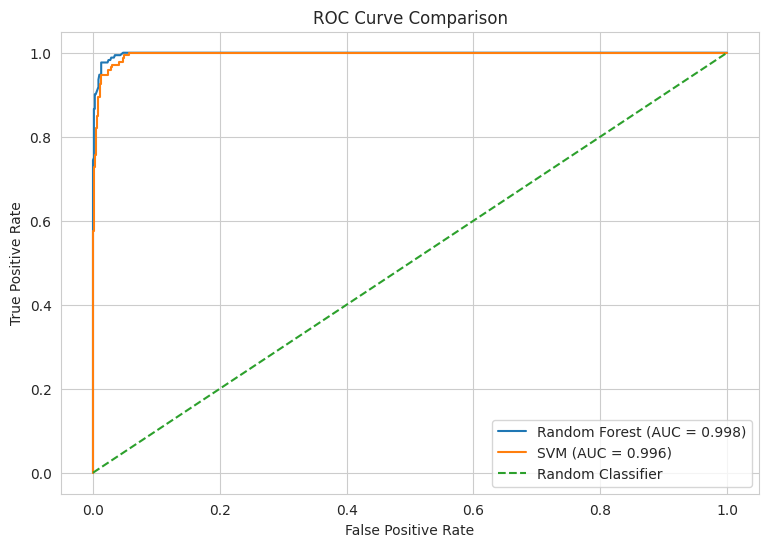

In [36]:

# ==========================================
# STEP 27: ROC CURVE COMPARISON
# ==========================================

from sklearn.metrics import roc_curve, auc

# Random Forest ROC
rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probabilities
)

rf_auc = auc(rf_fpr, rf_tpr)

# SVM ROC
svm_fpr, svm_tpr, _ = roc_curve(
    y_test,
    svm_probabilities
)

svm_auc = auc(svm_fpr, svm_tpr)

# Plot ROC Curves
plt.figure(figsize=(9, 6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

plt.plot(
    svm_fpr,
    svm_tpr,
    label=f'SVM (AUC = {svm_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()
plt.grid(True)
plt.show()

In [37]:

# ==========================================
# STEP 28: INTERACTIVE 3D VISUALIZATION
# ==========================================

import plotly.express as px
from sklearn.decomposition import PCA

# Reduce six features to three dimensions
pca_3d = PCA(n_components=3)

components_3d = pca_3d.fit_transform(rfm_scaled)

# Prepare visualization dataframe
plot_df = pd.DataFrame(
    components_3d,
    columns=['PC1', 'PC2', 'PC3'],
    index=rfm.index
)

plot_df['Cluster'] = rfm['Cluster'].astype(str)
plot_df['CustomerID'] = rfm.index

# Interactive 3D scatter plot
fig = px.scatter_3d(
    plot_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    hover_data=['CustomerID'],
    title='3D Customer Segmentation using K-Means',
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_traces(marker=dict(size=3, opacity=0.7))

fig.update_layout(
    scene=dict(
        xaxis_title='Principal Component 1',
        yaxis_title='Principal Component 2',
        zaxis_title='Principal Component 3'
    )
)

fig.show()

print(
    "3D PCA Explained Variance:",
    round(pca_3d.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

3D PCA Explained Variance: 92.32 %


In [38]:

# ==========================================
# STEP 29: MARKETING RECOMMENDATIONS
# ==========================================

marketing = pd.DataFrame({
    'Cluster': [0, 1, 2],
    'Customer Segment': [
        'Lower Spending Customers',
        'High Spending Customers',
        'Medium Spending Customers'
    ],
    'Marketing Strategy': [
        'Discounts, re-engagement emails and special offers',
        'VIP membership, loyalty rewards and exclusive offers',
        'Cross-selling, product recommendations and personalized offers'
    ]
})

display(marketing)

,Cluster,Customer Segment,Marketing Strategy
0,0,Lower Spending Customers,"Discounts, re-engagement emails and special of..."
1,1,High Spending Customers,"VIP membership, loyalty rewards and exclusive ..."
2,2,Medium Spending Customers,"Cross-selling, product recommendations and per..."


FINAL MACHINE LEARNING MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9781,0.9873,0.9012,0.9422,0.9982
1,SVM,0.9654,0.8698,0.9709,0.9176,0.9962


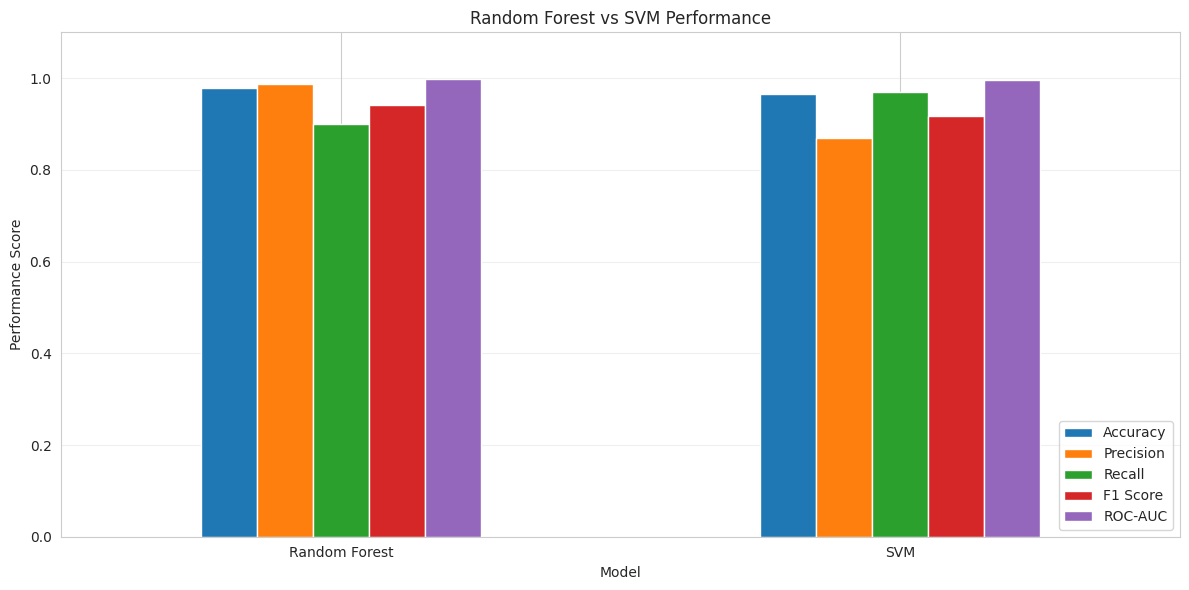

In [39]:

# ==========================================
# STEP 30: FINAL MODEL COMPARISON
# ==========================================

final_results = results_df.copy()

print("FINAL MACHINE LEARNING MODEL COMPARISON")

display(final_results.round(4))

# Plot model comparison
final_results.set_index('Model').plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Random Forest vs SVM Performance")
plt.ylabel("Performance Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()